# 03 — Exploratory Data Analysis (EDA)

## Objective
Understand what booking-time signals separate completed rides
from driver-cancelled and user-cancelled rides in Bangalore.

## Key Mental Shift from Regression EDA
In surge pricing EDA, we asked "what drives surge UP?"
Here, we ask "does this feature look DIFFERENT across the
three outcome classes?" Features that separate classes well
will be strong model predictors. Features that look identical
across classes carry no predictive signal.

## Business Questions We Answer
1. How does wait time differ across outcomes?
2. How does driver distance to pickup affect cancellation type?
3. Does surge at booking drive user cancellations?
4. Do habitual cancellers (users/drivers) show clearly?
5. How do cancellations vary by hour of day?
6. How do cancellations vary by day of week and month?
7. Does weather condition affect cancellation rates?
8. Which zones have highest cancellation rates?
9. What does driver reliability profile tell us?
10. What combination of factors creates highest cancellation risk?

## Data Leakage Rule Enforced Throughout
Only booking-time features are analyzed as predictors.
distance_km, fare_amount, duration_min, cancelled_by,
cancellation_reason, time_to_cancellation_min are
NEVER used as predictive features — only the target
variable (ride_outcome) is used to color/split charts.

## Data Used
Cleaned tables from data/processed/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.titleweight"]  = "bold"

# Consistent colors for the 3 outcome classes throughout notebook
OUTCOME_COLORS = {
    0: "#4CAF50",   # Completed — green
    1: "#F44336",   # Driver cancel — red
    2: "#FF9800",   # User cancel — orange
}
OUTCOME_LABELS = {
    0: "Completed",
    1: "Driver Cancel",
    2: "User Cancel"
}

print("Libraries loaded ✅")
print(f"Outcome colors: {OUTCOME_COLORS}")

c:\Users\dsp96\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\dsp96\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded ✅
Outcome colors: {0: '#4CAF50', 1: '#F44336', 2: '#FF9800'}


In [2]:
PATH = "../data/processed/"

rides_df = pd.read_csv(PATH + "rides_clean.csv", parse_dates=["ride_timestamp"])

print(f"Cleaned rides loaded ✅")
print(f"  Shape : {rides_df.shape}")
print(f"\nTarget distribution:")
for k, v in rides_df["ride_outcome"].value_counts().sort_index().items():
    pct = v / len(rides_df) * 100
    print(f"  {OUTCOME_LABELS[k]:<20}: {v:>7,}  ({pct:.1f}%)")

Cleaned rides loaded ✅
  Shape : (60000, 34)

Target distribution:
  Completed           :  46,597  (77.7%)
  Driver Cancel       :   3,922  (6.5%)
  User Cancel         :   9,481  (15.8%)


## Helper Setup — Cancellation Rate Calculator

Throughout this notebook we use a consistent metric called
"cancellation rate" per group:

cancellation_rate = (driver_cancels + user_cancels) / total_rides

We also look at DRIVER cancellation rate and USER cancellation
rate separately — because the factors that drive each are different.

We build a helper function once and reuse it everywhere.

In [3]:
def cancellation_rates_by(df, groupby_col):
    """
    For each unique value of groupby_col, calculate:
    - total rides
    - completed rate
    - driver cancel rate
    - user cancel rate
    - overall cancel rate
    Returns a sorted DataFrame.
    """
    grouped = df.groupby(groupby_col)["ride_outcome"].value_counts(
        normalize=False
    ).unstack(fill_value=0).reset_index()

    # Ensure all 3 outcome columns exist
    for col in [0, 1, 2]:
        if col not in grouped.columns:
            grouped[col] = 0

    grouped.columns = [groupby_col, "completed", "driver_cancel", "user_cancel"]
    grouped["total"]             = grouped[["completed","driver_cancel","user_cancel"]].sum(axis=1)
    grouped["completed_rate"]    = grouped["completed"]     / grouped["total"]
    grouped["driver_cancel_rate"]= grouped["driver_cancel"] / grouped["total"]
    grouped["user_cancel_rate"]  = grouped["user_cancel"]   / grouped["total"]
    grouped["overall_cancel_rate"]= (grouped["driver_cancel"] + grouped["user_cancel"]) / grouped["total"]

    return grouped.sort_values("overall_cancel_rate", ascending=False)


print("Helper function defined ✅")

Helper function defined ✅


## Section 1 — Wait Time & Driver Distance
### Question: Do wait time and driver distance separate the 3 classes?

These are the two most direct operational signals:
- Wait time: if driver is taking too long, USER is likely to cancel
- Driver distance: if driver is far from pickup, DRIVER is likely to cancel

If our data generator logic worked correctly, we should see:
- User cancel rides have higher estimated_wait_time_min
- Driver cancel rides have higher driver_distance_to_pickup_km

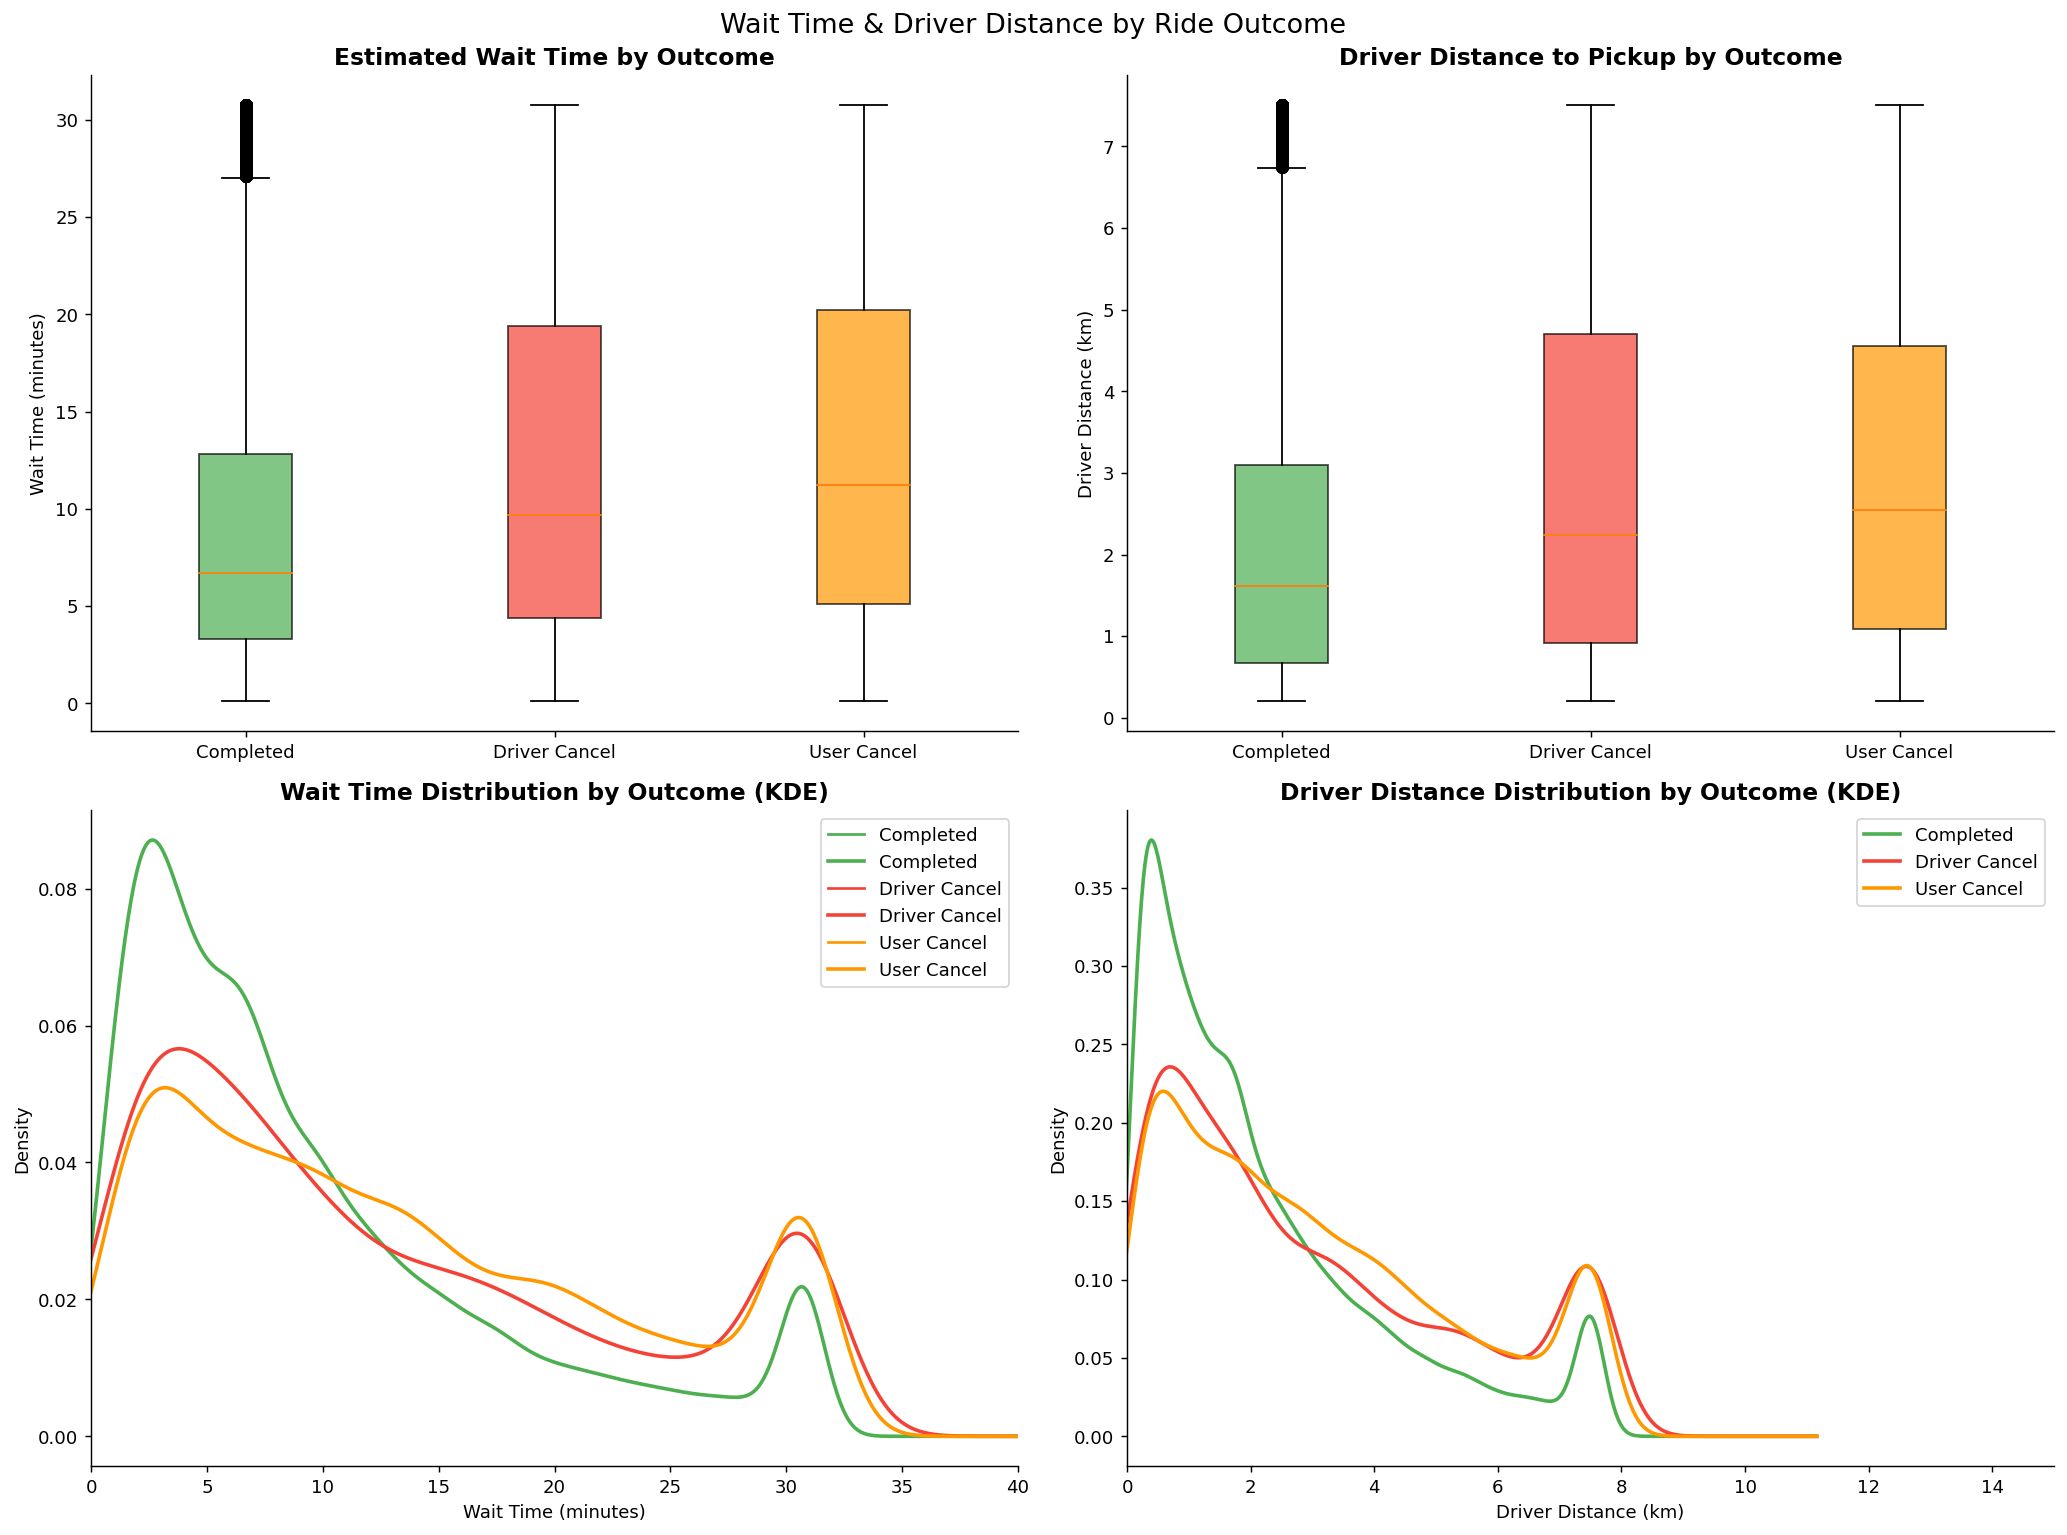

Mean values by outcome:

  Completed:
    avg wait time    : 9.36 min
    avg driver dist  : 2.19 km

  Driver Cancel:
    avg wait time    : 12.67 min
    avg driver dist  : 2.97 km

  User Cancel:
    avg wait time    : 13.33 min
    avg driver dist  : 3.04 km


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Wait Time & Driver Distance by Ride Outcome", fontsize=15)

# ── Boxplots ──────────────────────────────────────────────────
# Wait time by outcome
data_wait = [
    rides_df[rides_df["ride_outcome"]==k]["estimated_wait_time_min"].dropna()
    for k in [0, 1, 2]
]
bp1 = axes[0][0].boxplot(data_wait, patch_artist=True,
                          labels=[OUTCOME_LABELS[k] for k in [0,1,2]])
for patch, k in zip(bp1["boxes"], [0,1,2]):
    patch.set_facecolor(OUTCOME_COLORS[k])
    patch.set_alpha(0.7)
axes[0][0].set_title("Estimated Wait Time by Outcome")
axes[0][0].set_ylabel("Wait Time (minutes)")

# Driver distance by outcome
data_dist = [
    rides_df[rides_df["ride_outcome"]==k]["driver_distance_to_pickup_km"].dropna()
    for k in [0, 1, 2]
]
bp2 = axes[0][1].boxplot(data_dist, patch_artist=True,
                          labels=[OUTCOME_LABELS[k] for k in [0,1,2]])
for patch, k in zip(bp2["boxes"], [0,1,2]):
    patch.set_facecolor(OUTCOME_COLORS[k])
    patch.set_alpha(0.7)
axes[0][1].set_title("Driver Distance to Pickup by Outcome")
axes[0][1].set_ylabel("Driver Distance (km)")

# ── KDE Distributions ─────────────────────────────────────────
for k in [0, 1, 2]:
    subset = rides_df[rides_df["ride_outcome"]==k]["estimated_wait_time_min"].dropna()
    axes[1][0].plot([], [], color=OUTCOME_COLORS[k], label=OUTCOME_LABELS[k])
    subset.plot.kde(ax=axes[1][0], color=OUTCOME_COLORS[k],
                    linewidth=2, label=OUTCOME_LABELS[k])
axes[1][0].set_title("Wait Time Distribution by Outcome (KDE)")
axes[1][0].set_xlabel("Wait Time (minutes)")
axes[1][0].set_ylabel("Density")
axes[1][0].legend()
axes[1][0].set_xlim(0, 40)

for k in [0, 1, 2]:
    subset = rides_df[rides_df["ride_outcome"]==k]["driver_distance_to_pickup_km"].dropna()
    subset.plot.kde(ax=axes[1][1], color=OUTCOME_COLORS[k],
                    linewidth=2, label=OUTCOME_LABELS[k])
axes[1][1].set_title("Driver Distance Distribution by Outcome (KDE)")
axes[1][1].set_xlabel("Driver Distance (km)")
axes[1][1].set_ylabel("Density")
axes[1][1].legend()
axes[1][1].set_xlim(0, 15)

plt.tight_layout()
plt.savefig("../data/processed/eda_01_wait_distance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean values by outcome:")
for k in [0, 1, 2]:
    subset = rides_df[rides_df["ride_outcome"]==k]
    print(f"\n  {OUTCOME_LABELS[k]}:")
    print(f"    avg wait time    : {subset['estimated_wait_time_min'].mean():.2f} min")
    print(f"    avg driver dist  : {subset['driver_distance_to_pickup_km'].mean():.2f} km")

### Observation
Write your own observation here after running the cell.

Look for:
- Is the User Cancel boxplot shifted RIGHT on wait time vs Completed?
- Is the Driver Cancel boxplot shifted RIGHT on driver distance vs Completed?
- Do the KDE curves separate clearly or overlap?

If your data generator logic worked, User Cancel should have
noticeably higher wait time, and Driver Cancel should have
noticeably higher driver distance.

## Section 2 — Surge at Booking
### Question: Does high surge trigger user cancellations specifically?

When a user books a ride and sees a 2.5x surge price, some
will immediately cancel and wait for surge to drop.
This should appear as: User Cancel rides have higher
surge_at_booking than Completed or Driver Cancel rides.

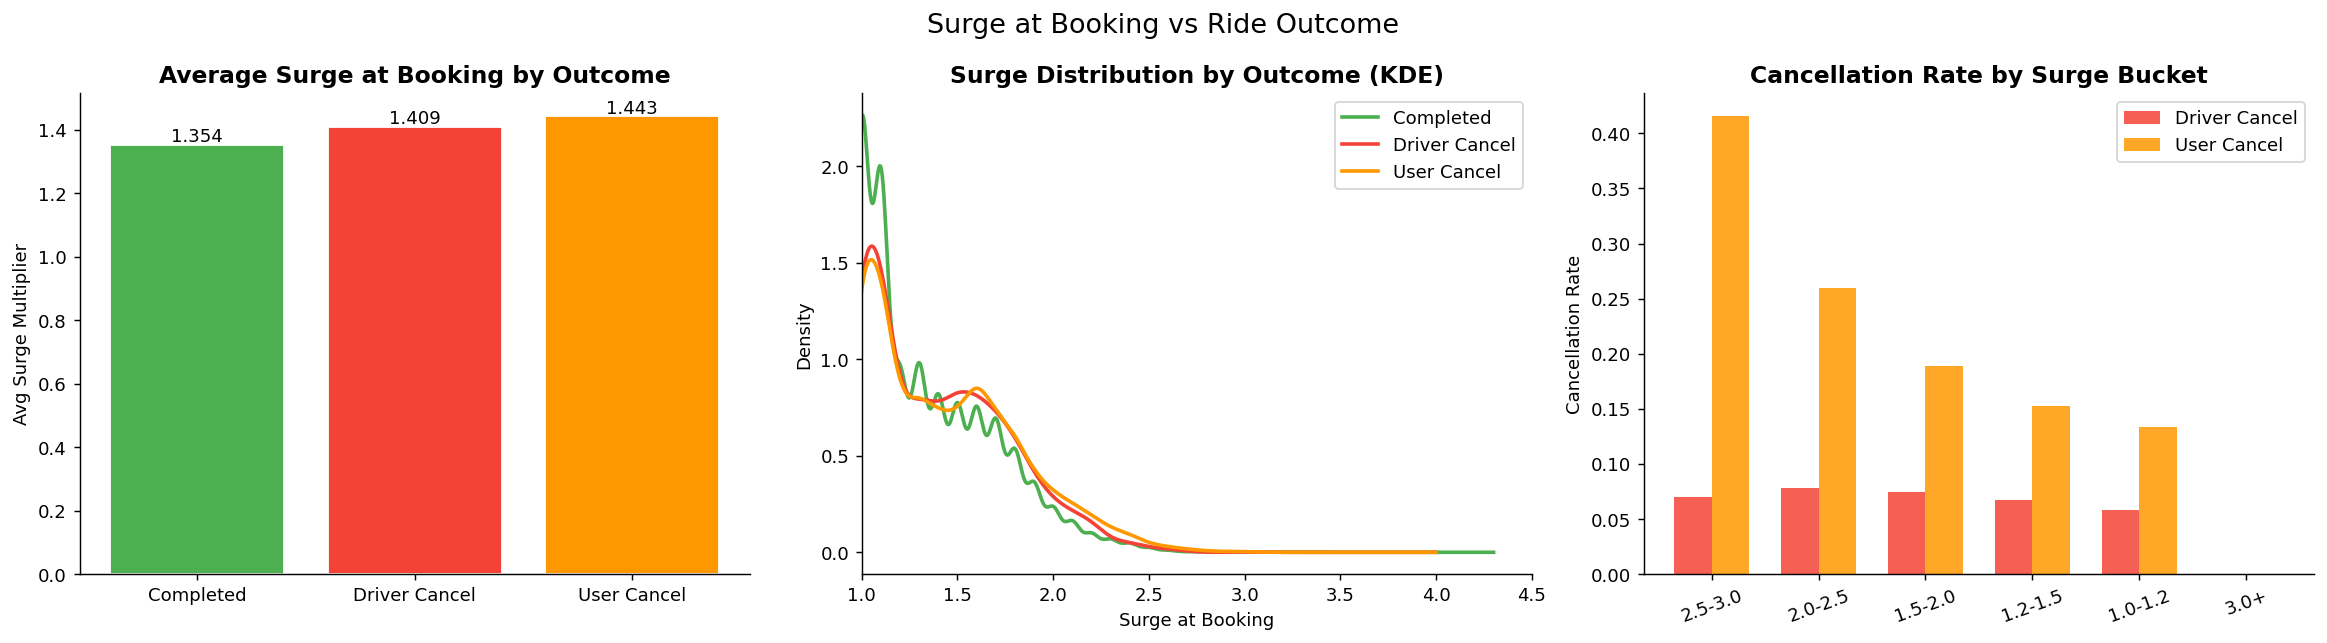

Surge at booking by outcome:
  Completed           : 1.354x
  Driver Cancel       : 1.409x
  User Cancel         : 1.443x


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Surge at Booking vs Ride Outcome", fontsize=15)

# Mean surge per outcome
surge_means = rides_df.groupby("ride_outcome")["surge_at_booking"].mean()

axes[0].bar(
    [OUTCOME_LABELS[k] for k in surge_means.index],
    surge_means.values,
    color=[OUTCOME_COLORS[k] for k in surge_means.index],
    edgecolor="white"
)
axes[0].set_title("Average Surge at Booking by Outcome")
axes[0].set_ylabel("Avg Surge Multiplier")
for i, (k, v) in enumerate(surge_means.items()):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# KDE of surge by outcome
for k in [0, 1, 2]:
    subset = rides_df[rides_df["ride_outcome"]==k]["surge_at_booking"].dropna()
    subset.plot.kde(ax=axes[1], color=OUTCOME_COLORS[k],
                    linewidth=2, label=OUTCOME_LABELS[k])
axes[1].set_title("Surge Distribution by Outcome (KDE)")
axes[1].set_xlabel("Surge at Booking")
axes[1].legend()
axes[1].set_xlim(1.0, 4.5)

# Cancellation rate by surge bucket
rides_df["surge_bucket"] = pd.cut(
    rides_df["surge_at_booking"],
    bins=[0.9, 1.2, 1.5, 2.0, 2.5, 3.0, 5.0],
    labels=["1.0-1.2", "1.2-1.5", "1.5-2.0", "2.0-2.5", "2.5-3.0", "3.0+"]
)
surge_cancel = cancellation_rates_by(rides_df, "surge_bucket")

x = np.arange(len(surge_cancel))
width = 0.35
axes[2].bar(x - width/2, surge_cancel["driver_cancel_rate"],
            width, label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
axes[2].bar(x + width/2, surge_cancel["user_cancel_rate"],
            width, label="User Cancel", color=OUTCOME_COLORS[2], alpha=0.85)
axes[2].set_title("Cancellation Rate by Surge Bucket")
axes[2].set_xticks(x)
axes[2].set_xticklabels(surge_cancel["surge_bucket"], rotation=20)
axes[2].set_ylabel("Cancellation Rate")
axes[2].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_02_surge_outcome.png", dpi=150, bbox_inches="tight")
plt.show()

print("Surge at booking by outcome:")
for k in [0, 1, 2]:
    mean_surge = rides_df[rides_df["ride_outcome"]==k]["surge_at_booking"].mean()
    print(f"  {OUTCOME_LABELS[k]:<20}: {mean_surge:.3f}x")

## Section 3 — Historical Cancellation Behavior
### Question: Do habitual cancellers (users and drivers) show
### clearly different patterns?

This tests whether past behavior predicts future behavior.
A user who has cancelled 8 times in the last 30 days is much
more likely to cancel again than someone who has never cancelled.

If this signal is strong, it will be one of our most
important features in the model.

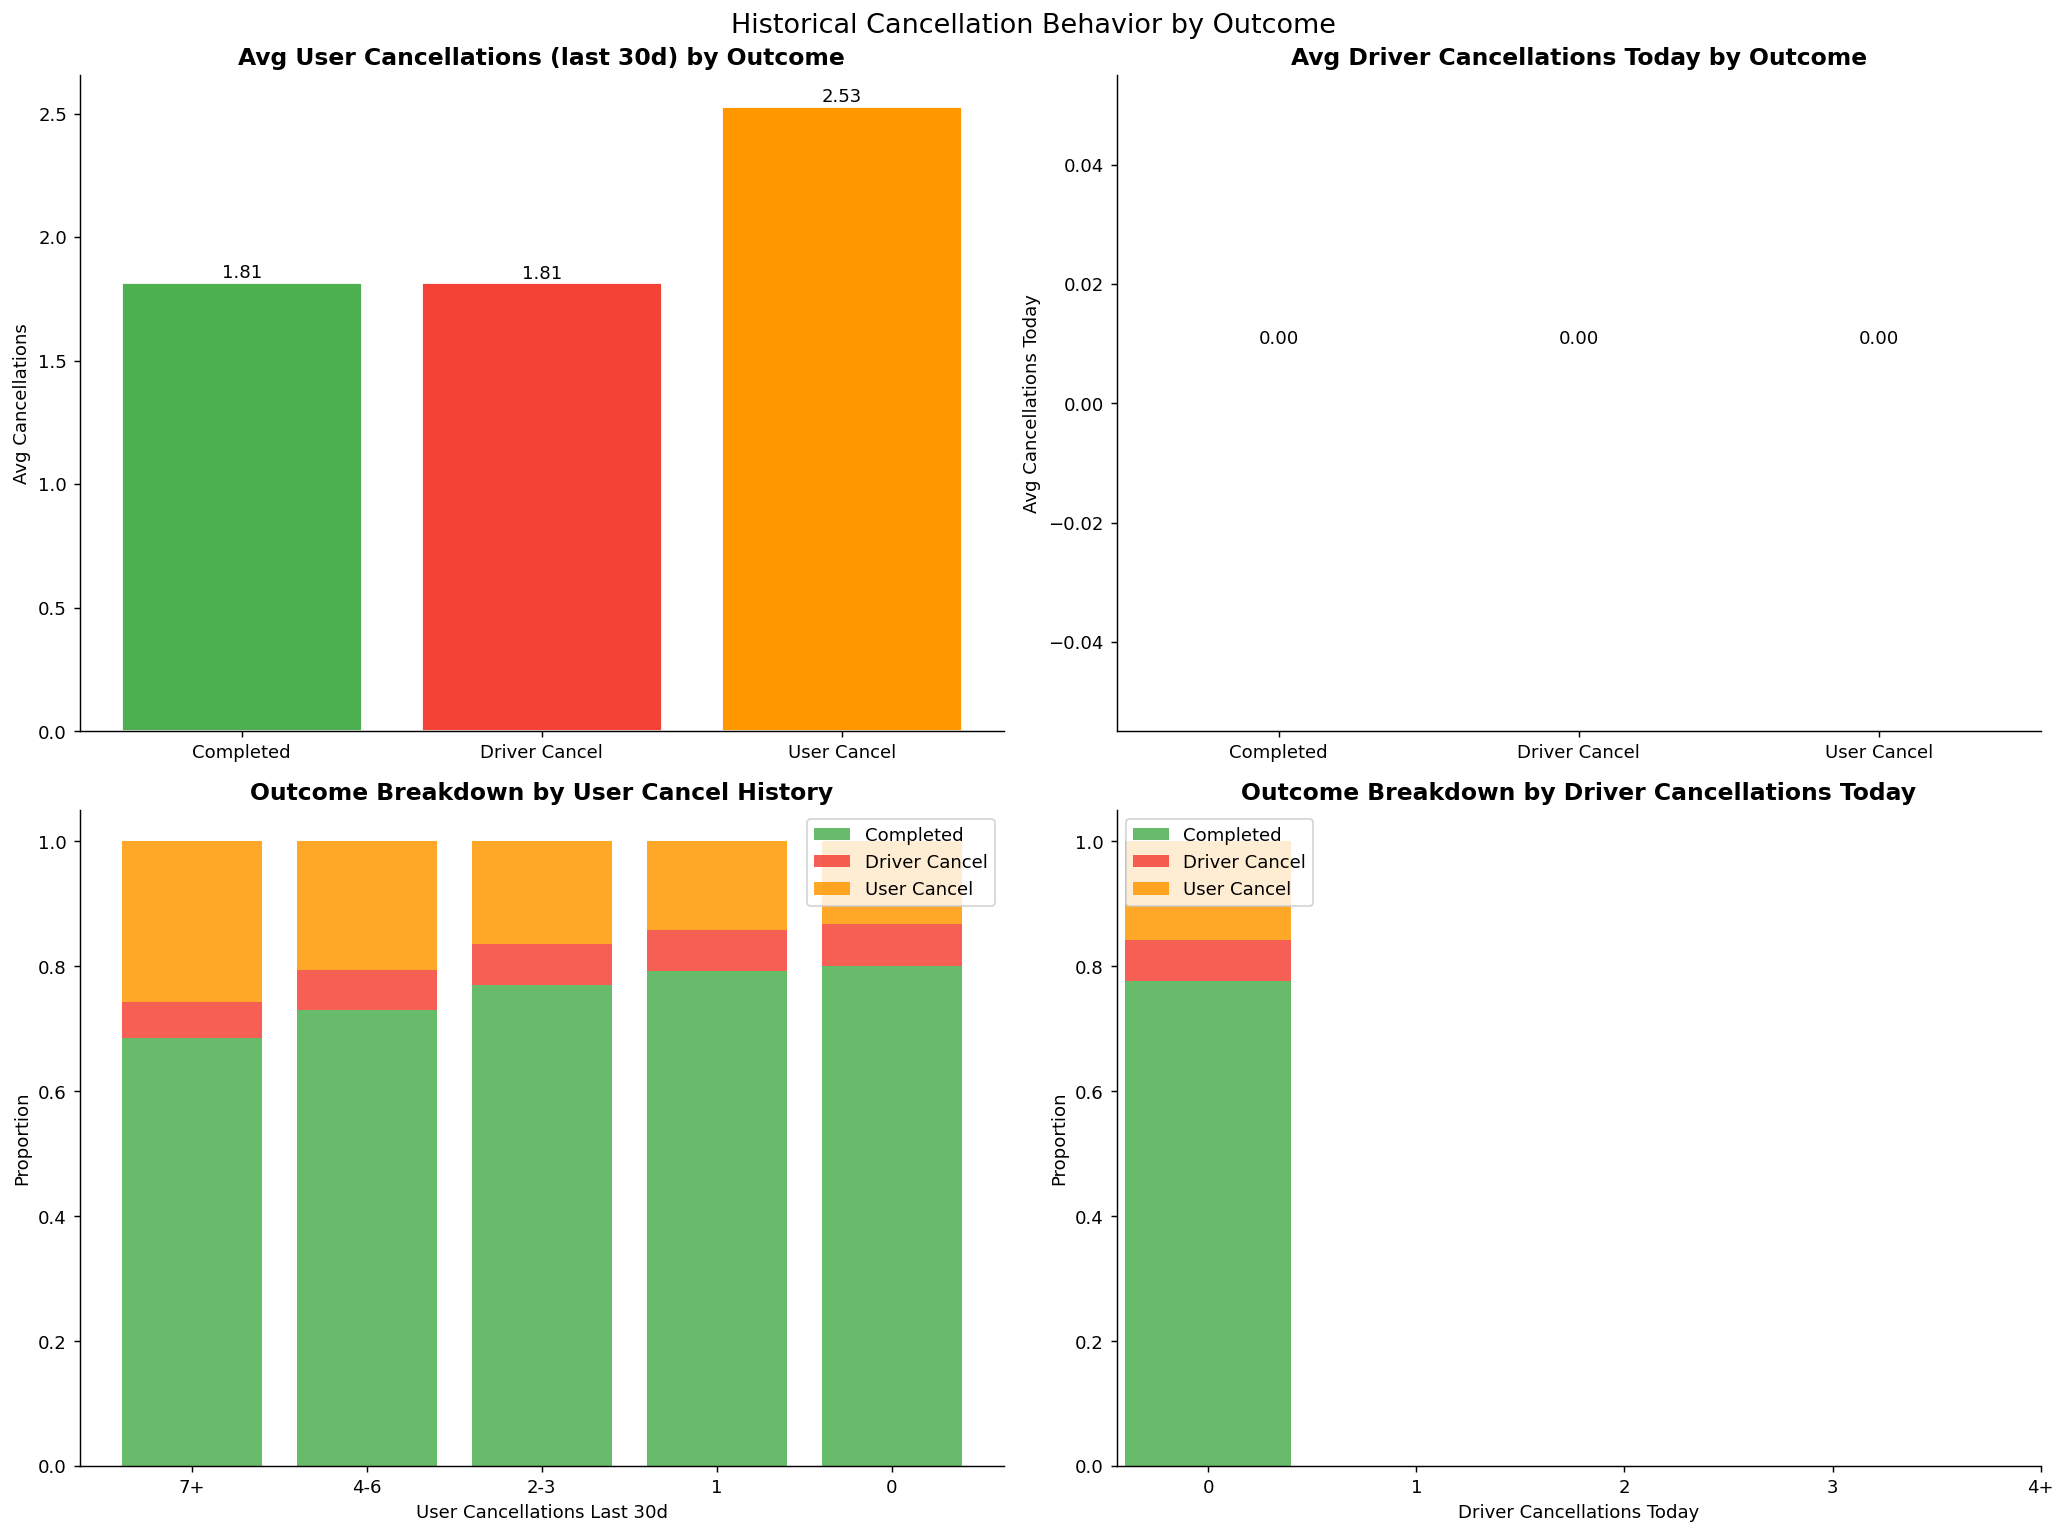

User cancellations last 30d by outcome:
  Completed           : 1.814
  Driver Cancel       : 1.813
  User Cancel         : 2.528

Driver cancellations today by outcome:
  Completed           : 0.000
  Driver Cancel       : 0.000
  User Cancel         : 0.000


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Historical Cancellation Behavior by Outcome", fontsize=15)

# User cancellations last 30d by outcome
user_cancel_means = rides_df.groupby("ride_outcome")["user_cancellations_last_30d"].mean()

axes[0][0].bar(
    [OUTCOME_LABELS[k] for k in user_cancel_means.index],
    user_cancel_means.values,
    color=[OUTCOME_COLORS[k] for k in user_cancel_means.index],
    edgecolor="white"
)
axes[0][0].set_title("Avg User Cancellations (last 30d) by Outcome")
axes[0][0].set_ylabel("Avg Cancellations")
for i, (k, v) in enumerate(user_cancel_means.items()):
    axes[0][0].text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=10)

# Driver cancellations today by outcome
driver_cancel_means = rides_df.groupby("ride_outcome")["driver_cancellations_today"].mean()

axes[0][1].bar(
    [OUTCOME_LABELS[k] for k in driver_cancel_means.index],
    driver_cancel_means.values,
    color=[OUTCOME_COLORS[k] for k in driver_cancel_means.index],
    edgecolor="white"
)
axes[0][1].set_title("Avg Driver Cancellations Today by Outcome")
axes[0][1].set_ylabel("Avg Cancellations Today")
for i, (k, v) in enumerate(driver_cancel_means.items()):
    axes[0][1].text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=10)

# User cancellation history — stacked buckets
rides_df["user_cancel_bucket"] = pd.cut(
    rides_df["user_cancellations_last_30d"],
    bins=[-1, 0, 1, 3, 6, 50],
    labels=["0", "1", "2-3", "4-6", "7+"]
)
user_bucket_rates = cancellation_rates_by(rides_df, "user_cancel_bucket")

x = np.arange(len(user_bucket_rates))
axes[1][0].bar(x, user_bucket_rates["completed_rate"],
               label="Completed", color=OUTCOME_COLORS[0], alpha=0.85)
axes[1][0].bar(x, user_bucket_rates["driver_cancel_rate"],
               bottom=user_bucket_rates["completed_rate"],
               label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
axes[1][0].bar(x, user_bucket_rates["user_cancel_rate"],
               bottom=user_bucket_rates["completed_rate"] + user_bucket_rates["driver_cancel_rate"],
               label="User Cancel", color=OUTCOME_COLORS[2], alpha=0.85)
axes[1][0].set_title("Outcome Breakdown by User Cancel History")
axes[1][0].set_xticks(x)
axes[1][0].set_xticklabels(user_bucket_rates["user_cancel_bucket"])
axes[1][0].set_xlabel("User Cancellations Last 30d")
axes[1][0].set_ylabel("Proportion")
axes[1][0].legend()

# Driver cancellations today — stacked
rides_df["driver_cancel_bucket"] = pd.cut(
    rides_df["driver_cancellations_today"],
    bins=[-1, 0, 1, 2, 3, 20],
    labels=["0", "1", "2", "3", "4+"]
)
driver_bucket_rates = cancellation_rates_by(rides_df, "driver_cancel_bucket")

x2 = np.arange(len(driver_bucket_rates))
axes[1][1].bar(x2, driver_bucket_rates["completed_rate"],
               label="Completed", color=OUTCOME_COLORS[0], alpha=0.85)
axes[1][1].bar(x2, driver_bucket_rates["driver_cancel_rate"],
               bottom=driver_bucket_rates["completed_rate"],
               label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
axes[1][1].bar(x2, driver_bucket_rates["user_cancel_rate"],
               bottom=driver_bucket_rates["completed_rate"] + driver_bucket_rates["driver_cancel_rate"],
               label="User Cancel", color=OUTCOME_COLORS[2], alpha=0.85)
axes[1][1].set_title("Outcome Breakdown by Driver Cancellations Today")
axes[1][1].set_xticks(x2)
axes[1][1].set_xticklabels(driver_bucket_rates["driver_cancel_bucket"])
axes[1][1].set_xlabel("Driver Cancellations Today")
axes[1][1].set_ylabel("Proportion")
axes[1][1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_03_cancel_history.png", dpi=150, bbox_inches="tight")
plt.show()

print("User cancellations last 30d by outcome:")
for k in [0,1,2]:
    mean_val = rides_df[rides_df["ride_outcome"]==k]["user_cancellations_last_30d"].mean()
    print(f"  {OUTCOME_LABELS[k]:<20}: {mean_val:.3f}")

print("\nDriver cancellations today by outcome:")
for k in [0,1,2]:
    mean_val = rides_df[rides_df["ride_outcome"]==k]["driver_cancellations_today"].mean()
    print(f"  {OUTCOME_LABELS[k]:<20}: {mean_val:.3f}")

## Section 4 — Time Patterns
### Question: When during the day/week do cancellations peak?

We expect:
- Driver cancellations to be higher during peak hours
  (more rides available = driver more selective = cancels weak rides)
- User cancellations to be higher late at night
  (long wait + safety concerns + found alternate transport)

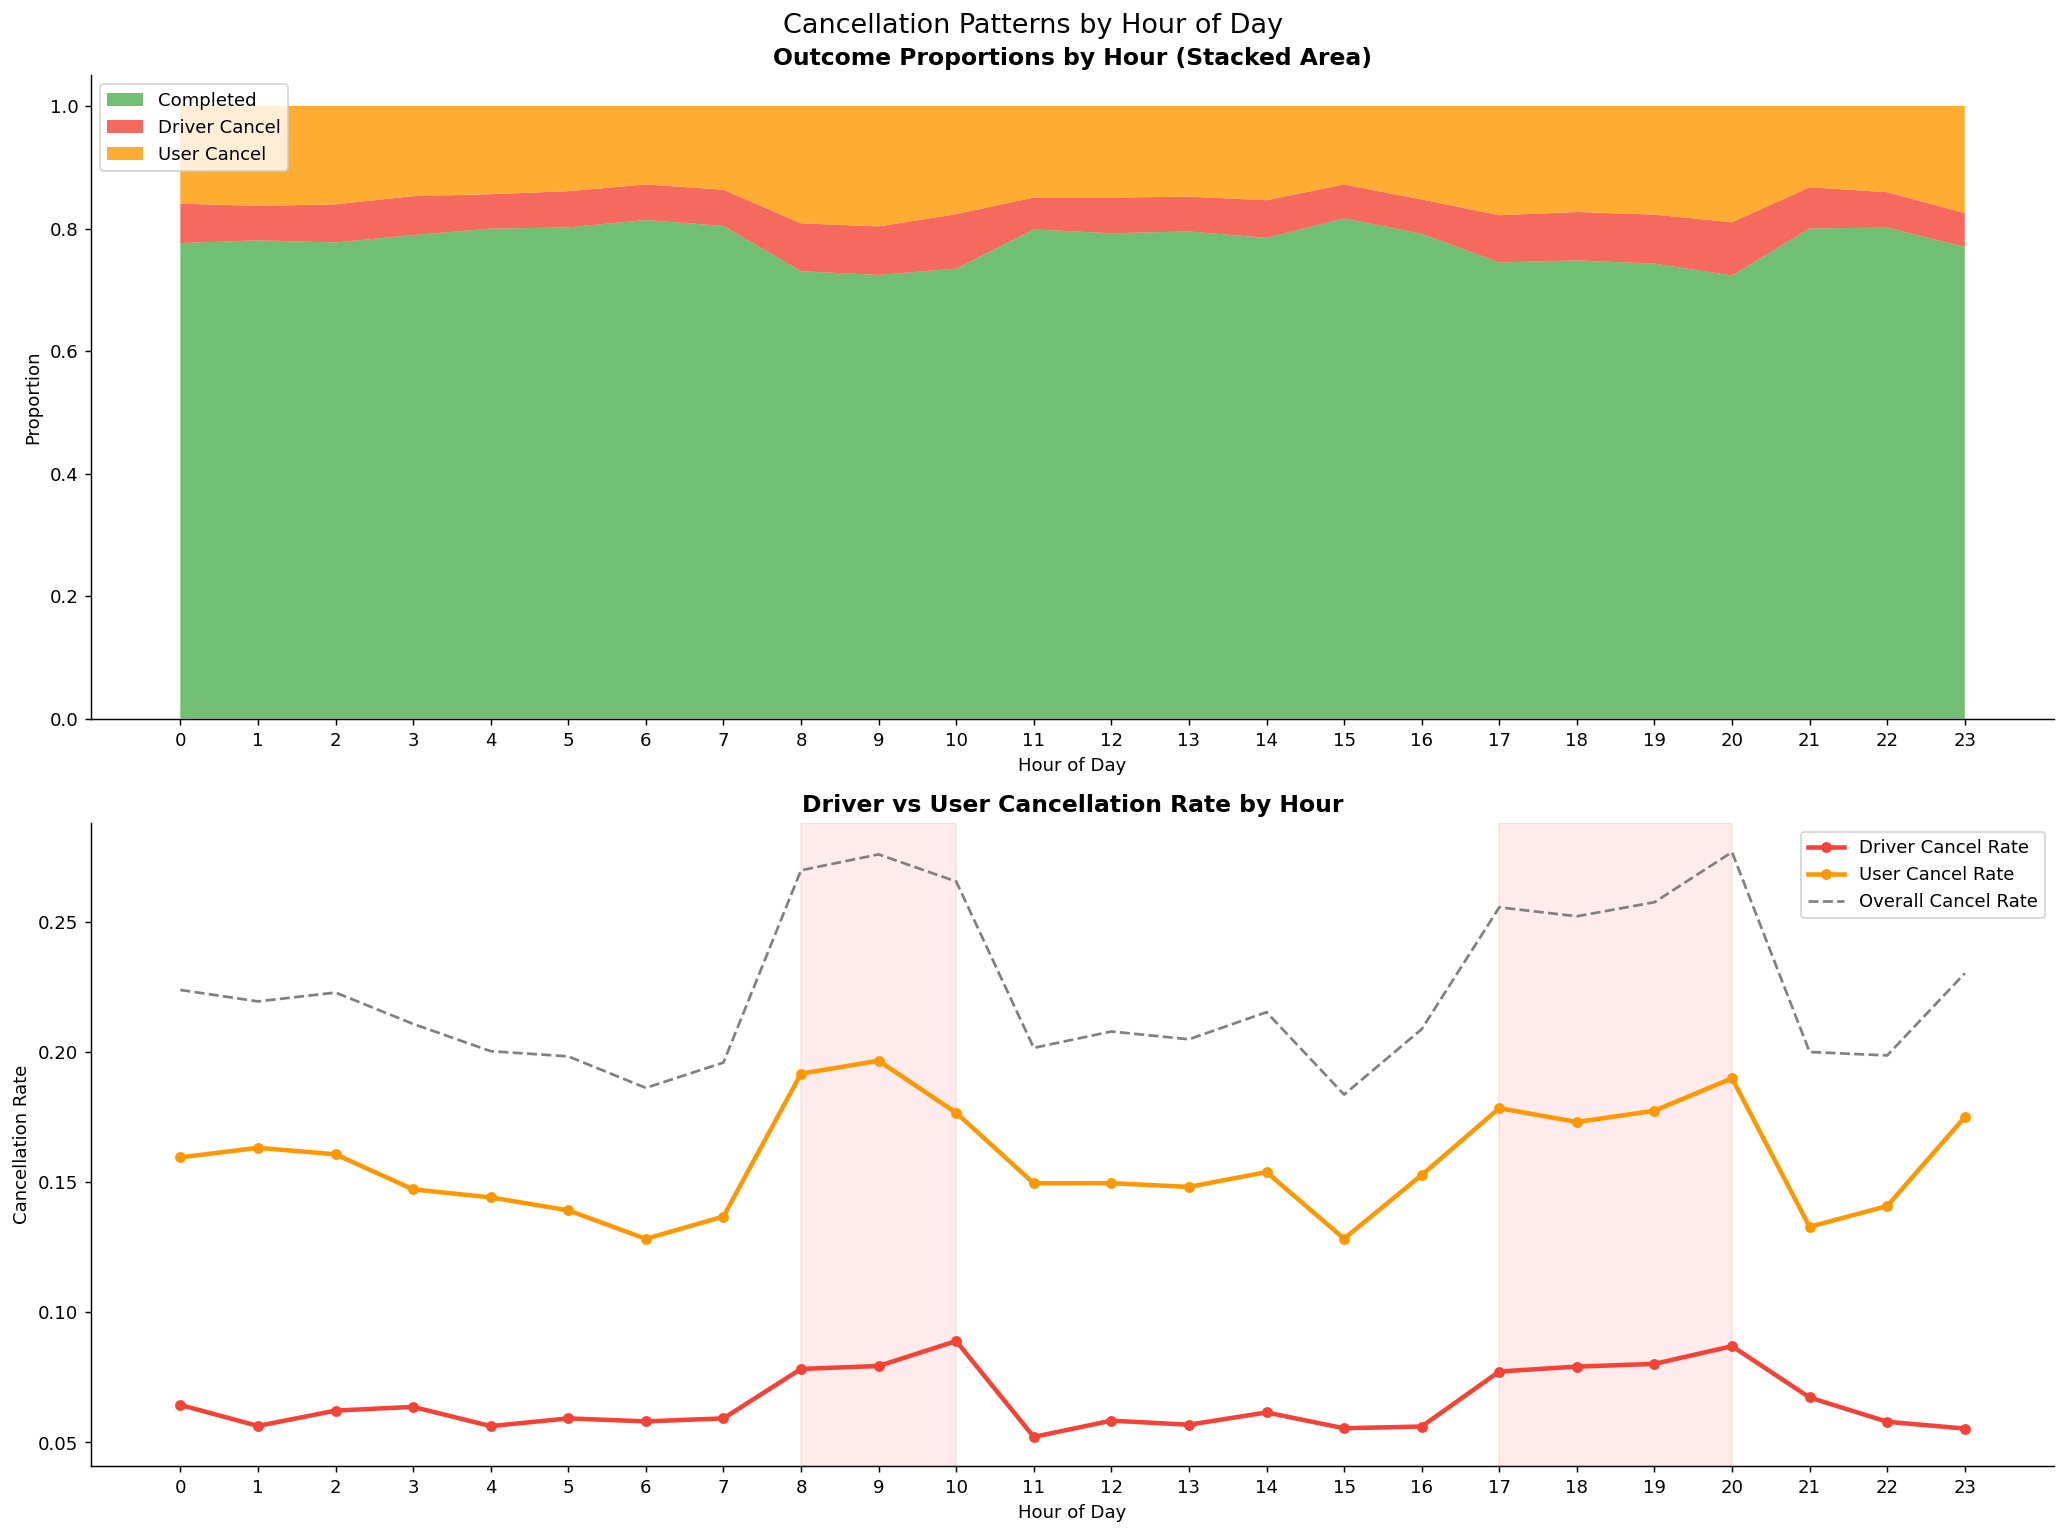

Top 5 hours by overall cancellation rate:
 hour  overall_cancel_rate  driver_cancel_rate  user_cancel_rate
    0                0.224               0.064             0.159
    1                0.219               0.056             0.163
    2                0.223               0.062             0.161
    3                0.211               0.064             0.147
    4                0.200               0.056             0.144


In [7]:
hourly_rates = cancellation_rates_by(rides_df, "hour")
hourly_rates = hourly_rates.sort_values("hour")

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle("Cancellation Patterns by Hour of Day", fontsize=15)

# Stacked area chart — outcome proportions by hour
axes[0].stackplot(
    hourly_rates["hour"],
    hourly_rates["completed_rate"],
    hourly_rates["driver_cancel_rate"],
    hourly_rates["user_cancel_rate"],
    labels=["Completed", "Driver Cancel", "User Cancel"],
    colors=[OUTCOME_COLORS[0], OUTCOME_COLORS[1], OUTCOME_COLORS[2]],
    alpha=0.8
)
axes[0].set_title("Outcome Proportions by Hour (Stacked Area)")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Proportion")
axes[0].set_xticks(range(0, 24))
axes[0].legend(loc="upper left")

# Line chart — just cancellation rates
axes[1].plot(hourly_rates["hour"], hourly_rates["driver_cancel_rate"],
             color=OUTCOME_COLORS[1], linewidth=2.5, marker="o",
             markersize=5, label="Driver Cancel Rate")
axes[1].plot(hourly_rates["hour"], hourly_rates["user_cancel_rate"],
             color=OUTCOME_COLORS[2], linewidth=2.5, marker="o",
             markersize=5, label="User Cancel Rate")
axes[1].plot(hourly_rates["hour"], hourly_rates["overall_cancel_rate"],
             color="gray", linewidth=1.5, linestyle="--",
             label="Overall Cancel Rate")
axes[1].set_title("Driver vs User Cancellation Rate by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Cancellation Rate")
axes[1].set_xticks(range(0, 24))
axes[1].legend()
axes[1].axvspan(8, 10, alpha=0.08, color="red", label="Morning peak")
axes[1].axvspan(17, 20, alpha=0.08, color="red", label="Evening peak")

plt.tight_layout()
plt.savefig("../data/processed/eda_04_hourly_cancellation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 hours by overall cancellation rate:")
print(hourly_rates[["hour","overall_cancel_rate","driver_cancel_rate",
                     "user_cancel_rate"]].head().to_string(index=False))

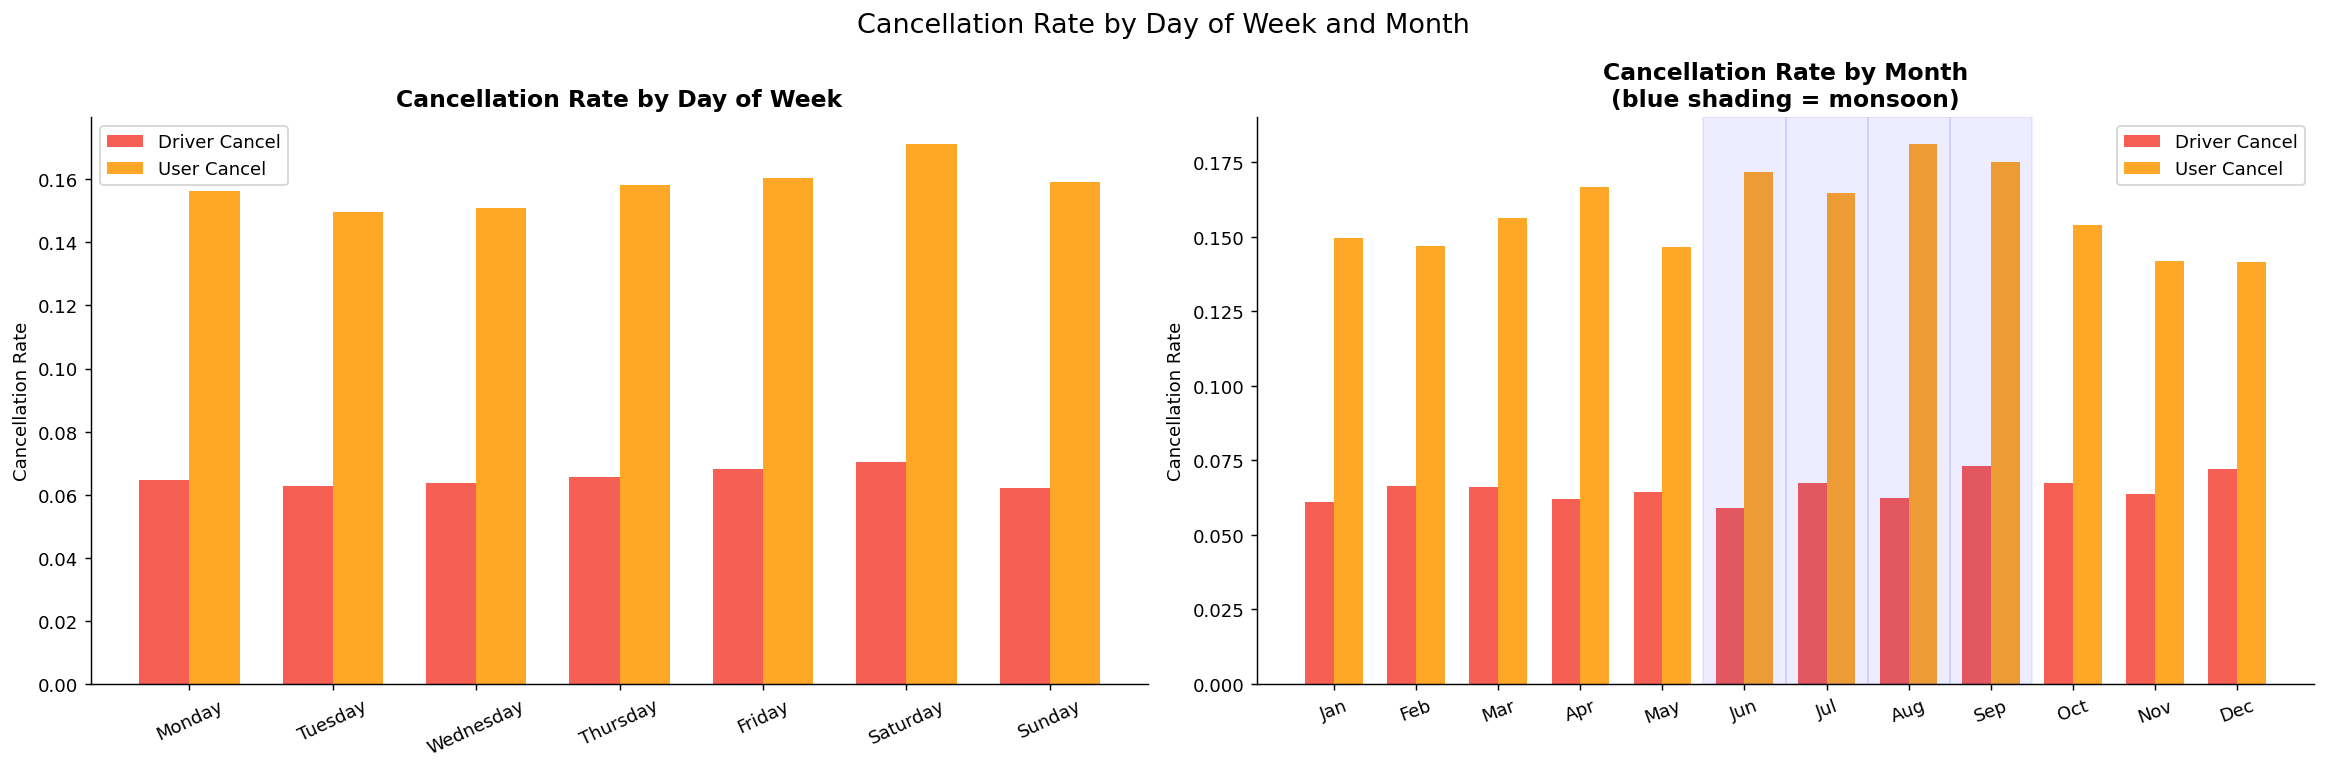

In [8]:
day_order   = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
month_labels= ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

daily_rates   = cancellation_rates_by(rides_df, "day_of_week").reindex(
    daily_rates["day_of_week"].map(
        {d:i for i,d in enumerate(day_order)}
    ).sort_values().index
) if False else cancellation_rates_by(rides_df, "day_of_week")

# reorder properly
daily_rates["day_order"] = daily_rates["day_of_week"].map(
    {d:i for i,d in enumerate(day_order)}
)
daily_rates = daily_rates.sort_values("day_order")

monthly_rates = cancellation_rates_by(rides_df, "month").sort_values("month")
monthly_rates["month_name"] = monthly_rates["month"].apply(
    lambda x: month_labels[int(x)-1]
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("Cancellation Rate by Day of Week and Month", fontsize=15)

# Day of week
x1 = np.arange(len(daily_rates))
width = 0.35
axes[0].bar(x1 - width/2, daily_rates["driver_cancel_rate"],
            width, label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
axes[0].bar(x1 + width/2, daily_rates["user_cancel_rate"],
            width, label="User Cancel", color=OUTCOME_COLORS[2], alpha=0.85)
axes[0].set_title("Cancellation Rate by Day of Week")
axes[0].set_xticks(x1)
axes[0].set_xticklabels(daily_rates["day_of_week"], rotation=25)
axes[0].set_ylabel("Cancellation Rate")
axes[0].legend()

# Monthly
x2 = np.arange(len(monthly_rates))
axes[1].bar(x2 - width/2, monthly_rates["driver_cancel_rate"],
            width, label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
axes[1].bar(x2 + width/2, monthly_rates["user_cancel_rate"],
            width, label="User Cancel", color=OUTCOME_COLORS[2], alpha=0.85)
for m in [5,6,7,8]:
    axes[1].axvspan(m - 0.5, m + 0.5, alpha=0.07, color="blue")
axes[1].set_title("Cancellation Rate by Month\n(blue shading = monsoon)")
axes[1].set_xticks(x2)
axes[1].set_xticklabels(monthly_rates["month_name"], rotation=20)
axes[1].set_ylabel("Cancellation Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_05_day_month_cancellation.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Section 5 — Weather and Zone Analysis
### Question: Does rain or zone affect cancellation patterns?

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

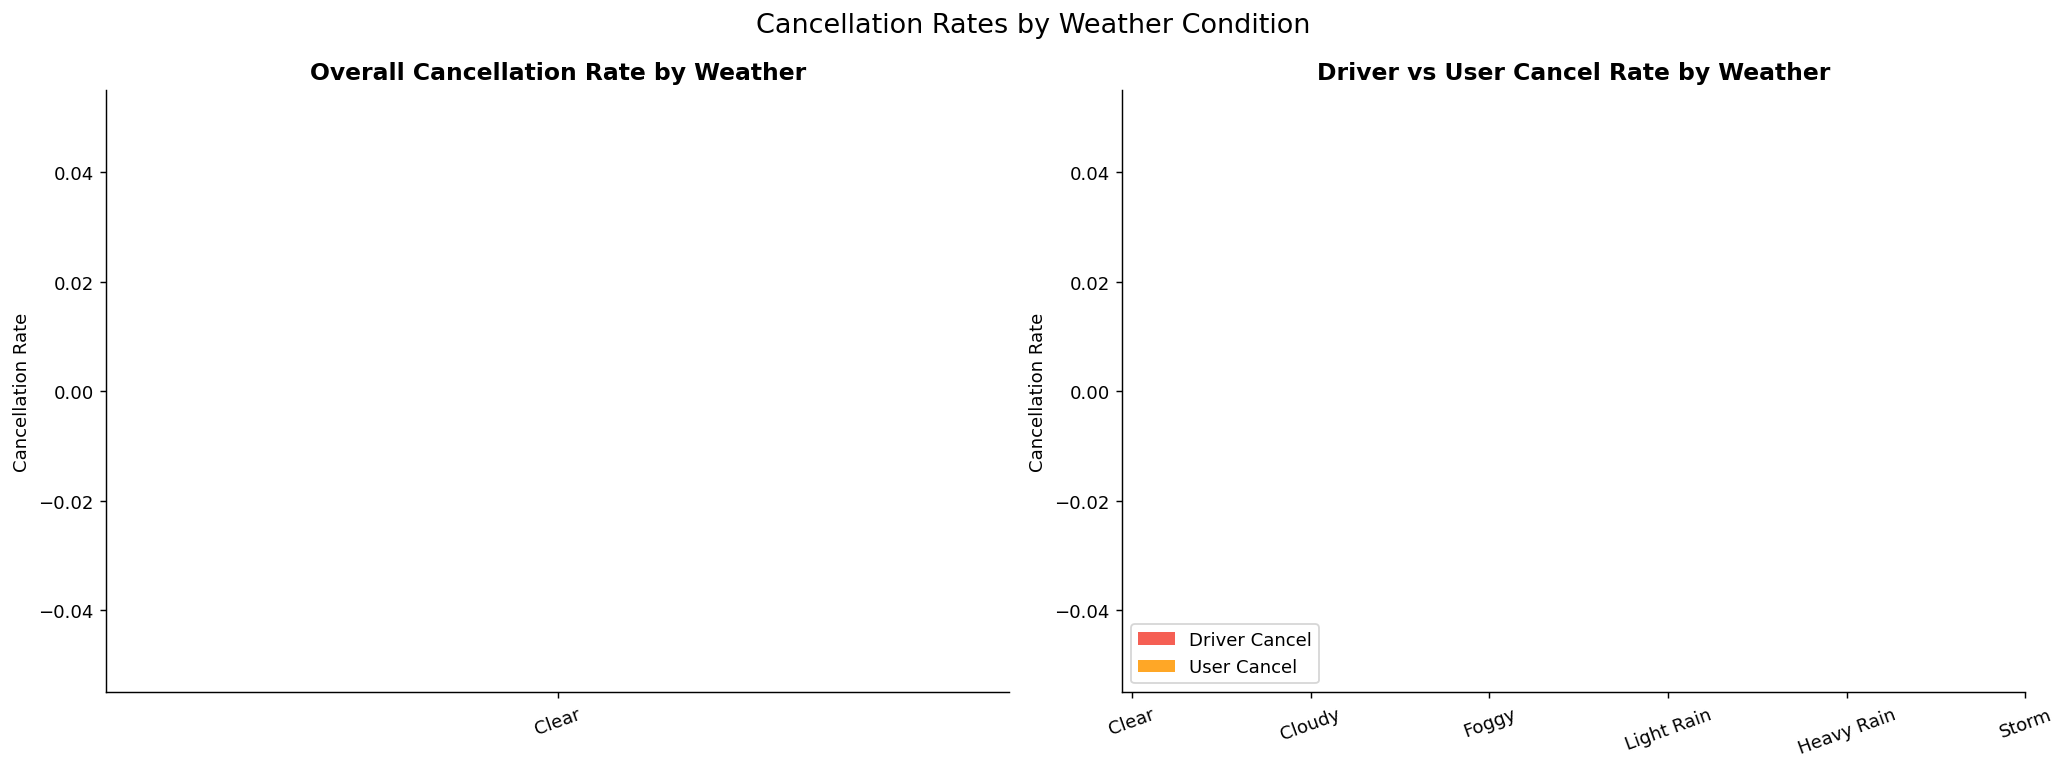

Weather cancellation summary:
weather_condition  overall_cancel_rate  driver_cancel_rate  user_cancel_rate
            Clear                  NaN                 NaN               NaN
           Cloudy                  NaN                 NaN               NaN
            Foggy                  NaN                 NaN               NaN
       Light Rain                  NaN                 NaN               NaN
       Heavy Rain                  NaN                 NaN               NaN
            Storm                  NaN                 NaN               NaN


In [9]:
weather_order = ["Clear","Cloudy","Foggy","Light Rain","Heavy Rain","Storm"]
weather_rates = cancellation_rates_by(rides_df, "weather_condition").reindex(
    pd.Index(weather_order)
).reset_index(drop=True)
weather_rates["weather_condition"] = weather_order

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Cancellation Rates by Weather Condition", fontsize=15)

colors_weather = ["#87CEEB","#B0BEC5","#CFD8DC","#64B5F6","#1565C0","#4A148C"]

# Overall cancel rate
axes[0].bar(weather_rates["weather_condition"],
            weather_rates["overall_cancel_rate"],
            color=colors_weather, edgecolor="white", alpha=0.9)
axes[0].set_title("Overall Cancellation Rate by Weather")
axes[0].set_ylabel("Cancellation Rate")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(weather_rates["overall_cancel_rate"]):
    axes[0].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)

# Driver vs User cancel by weather
x = np.arange(len(weather_rates))
width = 0.35
axes[1].bar(x - width/2, weather_rates["driver_cancel_rate"],
            width, label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
axes[1].bar(x + width/2, weather_rates["user_cancel_rate"],
            width, label="User Cancel", color=OUTCOME_COLORS[2], alpha=0.85)
axes[1].set_title("Driver vs User Cancel Rate by Weather")
axes[1].set_xticks(x)
axes[1].set_xticklabels(weather_rates["weather_condition"], rotation=20)
axes[1].set_ylabel("Cancellation Rate")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_06_weather_cancellation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Weather cancellation summary:")
print(weather_rates[["weather_condition","overall_cancel_rate",
                      "driver_cancel_rate","user_cancel_rate"]].to_string(index=False))

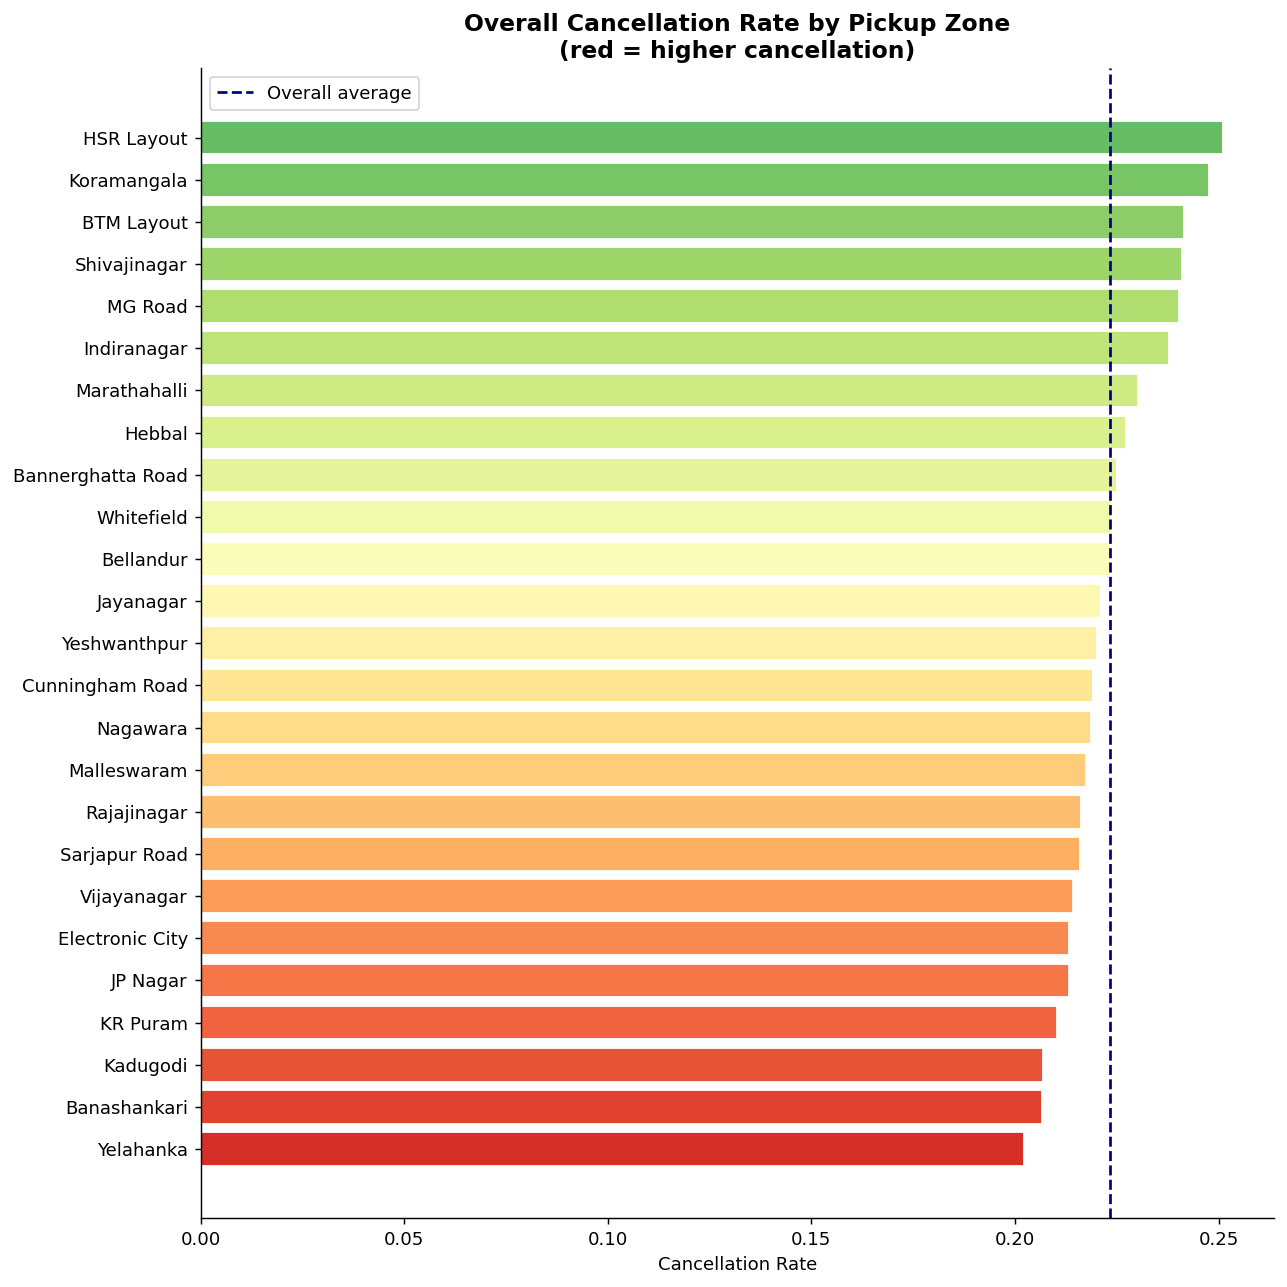

Top 5 highest cancellation zones:
 pickup_zone  overall_cancel_rate  driver_cancel_rate  user_cancel_rate  total
  HSR Layout                0.251               0.074             0.177   2358
 Koramangala                0.248               0.071             0.176   2254
  BTM Layout                0.242               0.078             0.164   2347
Shivajinagar                0.241               0.072             0.169   2336
     MG Road                0.240               0.069             0.171   2327

Bottom 5 lowest cancellation zones:
 pickup_zone  overall_cancel_rate  driver_cancel_rate  user_cancel_rate  total
    JP Nagar                0.213               0.062             0.151   2280
    KR Puram                0.210               0.058             0.153   2363
    Kadugodi                0.207               0.061             0.145   2297
Banashankari                0.207               0.057             0.150   2390
   Yelahanka                0.202               0.050       

In [10]:
zone_rates = cancellation_rates_by(rides_df, "pickup_zone")

fig, ax = plt.subplots(figsize=(10, 10))

colors_zone = plt.cm.RdYlGn_r(
    np.linspace(0.2, 0.9, len(zone_rates))
)

ax.barh(zone_rates["pickup_zone"],
        zone_rates["overall_cancel_rate"],
        color=colors_zone, edgecolor="white")
ax.set_title("Overall Cancellation Rate by Pickup Zone\n(red = higher cancellation)",
             fontsize=13)
ax.set_xlabel("Cancellation Rate")
ax.invert_yaxis()
ax.axvline(rides_df[rides_df["ride_outcome"]!=0].shape[0] / len(rides_df),
           color="navy", linestyle="--", linewidth=1.5, label="Overall average")
ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_07_zone_cancellation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 highest cancellation zones:")
print(zone_rates[["pickup_zone","overall_cancel_rate","driver_cancel_rate",
                   "user_cancel_rate","total"]].head().to_string(index=False))
print("\nBottom 5 lowest cancellation zones:")
print(zone_rates[["pickup_zone","overall_cancel_rate","driver_cancel_rate",
                   "user_cancel_rate","total"]].tail().to_string(index=False))

## Section 6 — Driver Reliability Profile
### Question: Does the reliability_profile column we built
### (reliable/average/unreliable) actually show in cancellation outcomes?

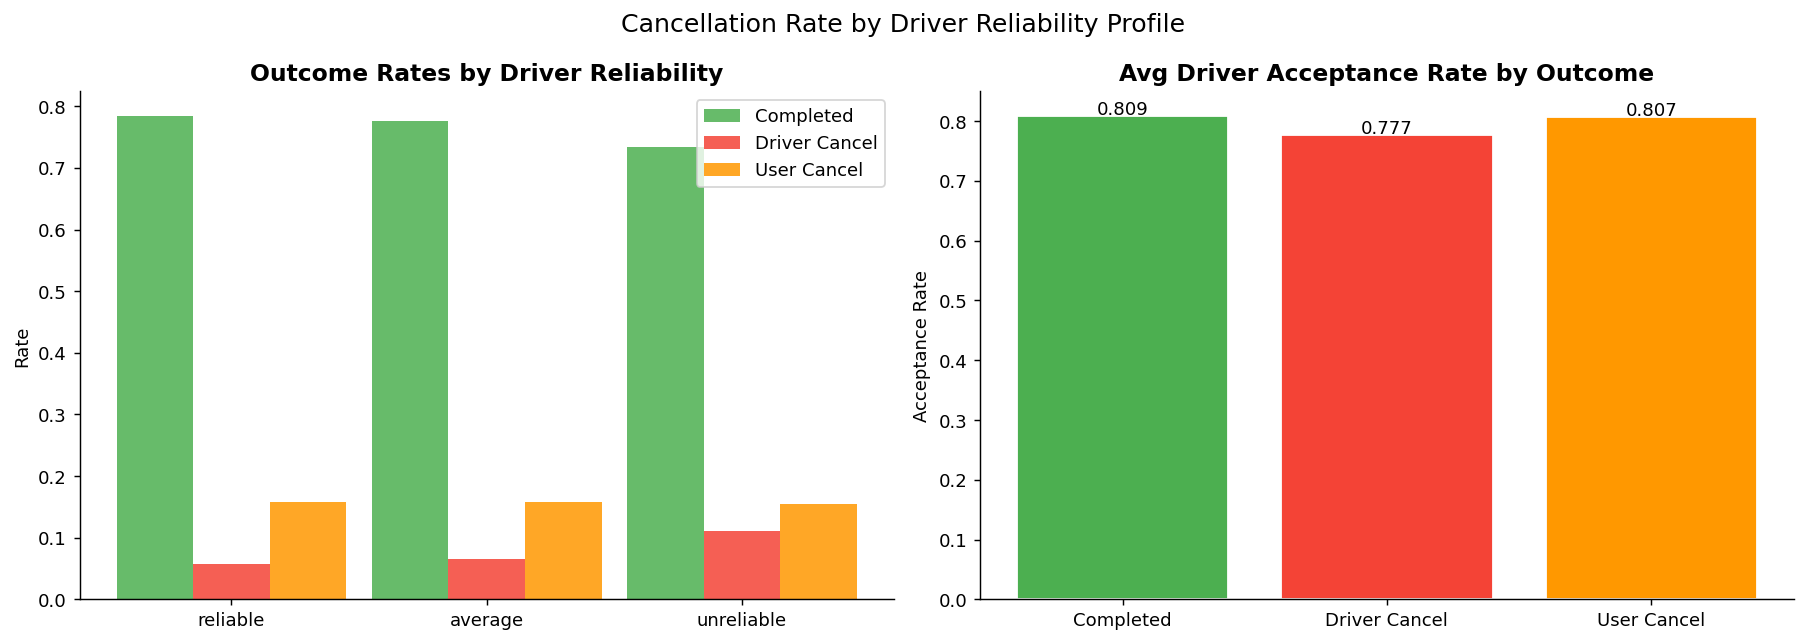

In [11]:
# Merge driver reliability profile onto rides
drivers_clean = pd.read_csv("../data/processed/drivers_clean.csv")
rides_with_driver = rides_df.merge(
    drivers_clean[["driver_id","reliability_profile"]],
    on="driver_id", how="left"
)

reliability_rates = cancellation_rates_by(rides_with_driver, "reliability_profile")
reliability_order = ["reliable","average","unreliable"]
reliability_rates = reliability_rates.set_index("reliability_profile").reindex(
    reliability_order
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cancellation Rate by Driver Reliability Profile", fontsize=14)

x = np.arange(len(reliability_rates))
width = 0.3

axes[0].bar(x - width, reliability_rates["completed_rate"],
            width, label="Completed", color=OUTCOME_COLORS[0], alpha=0.85)
axes[0].bar(x, reliability_rates["driver_cancel_rate"],
            width, label="Driver Cancel", color=OUTCOME_COLORS[1], alpha=0.85)
axes[0].bar(x + width, reliability_rates["user_cancel_rate"],
            width, label="User Cancel", color=OUTCOME_COLORS[2], alpha=0.85)
axes[0].set_title("Outcome Rates by Driver Reliability")
axes[0].set_xticks(x)
axes[0].set_xticklabels(reliability_order)
axes[0].set_ylabel("Rate")
axes[0].legend()

# Acceptance rate by outcome
accept_means = rides_df.groupby("ride_outcome")["driver_acceptance_rate"].mean()
axes[1].bar(
    [OUTCOME_LABELS[k] for k in accept_means.index],
    accept_means.values,
    color=[OUTCOME_COLORS[k] for k in accept_means.index],
    edgecolor="white"
)
axes[1].set_title("Avg Driver Acceptance Rate by Outcome")
axes[1].set_ylabel("Acceptance Rate")
for i, (k, v) in enumerate(accept_means.items()):
    axes[1].text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../data/processed/eda_08_driver_reliability.png",
            dpi=150, bbox_inches="tight")
plt.show()

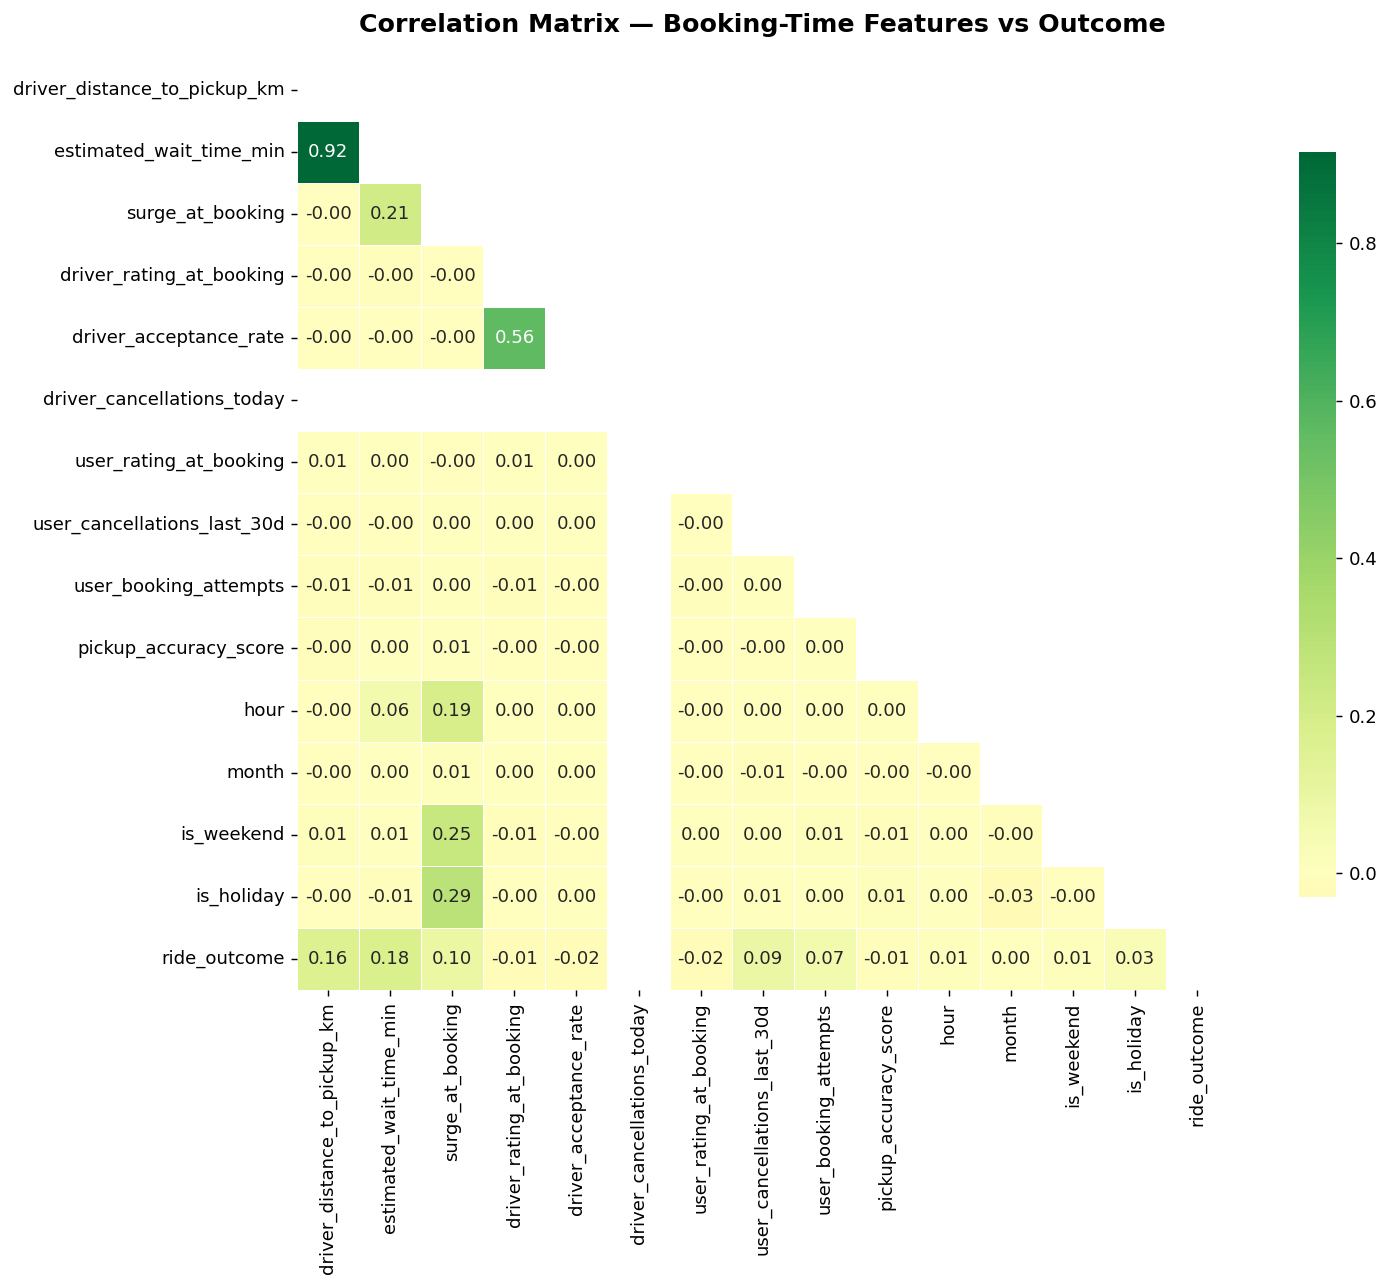

Correlation with ride_outcome (sorted by absolute value):
estimated_wait_time_min        0.181
driver_distance_to_pickup_km   0.161
surge_at_booking               0.097
user_cancellations_last_30d    0.093
user_booking_attempts          0.066
is_holiday                     0.033
driver_acceptance_rate         0.019
user_rating_at_booking         0.017
is_weekend                     0.013
driver_rating_at_booking       0.013
hour                           0.011
pickup_accuracy_score          0.007
month                          0.002
driver_cancellations_today       NaN
Name: ride_outcome, dtype: float64


In [12]:
# Only use booking-time numerical features for correlation
booking_features = [
    "driver_distance_to_pickup_km", "estimated_wait_time_min",
    "surge_at_booking", "driver_rating_at_booking",
    "driver_acceptance_rate", "driver_cancellations_today",
    "user_rating_at_booking", "user_cancellations_last_30d",
    "user_booking_attempts", "pickup_accuracy_score",
    "hour", "month", "is_weekend", "is_holiday",
    "ride_outcome"
]

booking_features = [c for c in booking_features if c in rides_df.columns]
corr_df = rides_df[booking_features].copy()
corr_df["is_weekend"] = corr_df["is_weekend"].astype(int)
corr_df["is_holiday"] = corr_df["is_holiday"].astype(int)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, square=True,
    linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Matrix — Booking-Time Features vs Outcome",
             fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eda_09_correlation_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with ride_outcome (sorted by absolute value):")
outcome_corr = corr_matrix["ride_outcome"].drop("ride_outcome").abs().sort_values(ascending=False)
print(outcome_corr.round(4))